In [1]:
import time
import numpy as np
import torch
import onnxruntime as ort
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer


# -----------------------------
# CONFIG
# -----------------------------
MODEL_NAME = "meta-llama/Llama-2-7b-chat-hf"
ONNX_PATH = "../save_dir/llama_final_int8_fixed_v4.onnx"  # your quantized ONNX model
PROMPT = "The capital of France is"
MAX_NEW_TOKENS = 20


# -----------------------------
# LOAD TOKENIZER
# -----------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


# -----------------------------
# 1. FULL PRECISION (PyTorch)
# -----------------------------
def run_full_precision():
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype=torch.float32,
        device_map="cpu"
    )
    model.eval()

    inputs = tokenizer(PROMPT, return_tensors="pt")
    input_ids = inputs["input_ids"]
    attention_mask = inputs["attention_mask"]

    generated_tokens = []

    start = time.perf_counter()

    for _ in range(MAX_NEW_TOKENS):
        with torch.no_grad():
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        logits = outputs.logits[:, -1, :]
        next_token = torch.argmax(logits, dim=-1).unsqueeze(0)

        generated_tokens.append(next_token.item())

        input_ids = torch.cat([input_ids, next_token], dim=-1)
        attention_mask = torch.cat(
            [attention_mask, torch.ones((1, 1), dtype=torch.long)],
            dim=-1
        )

        if next_token.item() == tokenizer.eos_token_id:
            break

    end = time.perf_counter()

    total_time = end - start
    num_tokens = len(generated_tokens)
    speed = num_tokens / total_time

    output = tokenizer.decode(generated_tokens)

    print("\n--- FULL PRECISION ---")
    print("Output:", output)
    print(f"Speed: {speed:.2f} tokens/sec")

    return speed


# -----------------------------
# 2. QUANTIZED (ONNX)
# -----------------------------
def run_onnx():
    session = ort.InferenceSession(ONNX_PATH)

    inputs = tokenizer(PROMPT, return_tensors="np")
    input_ids = inputs["input_ids"].astype(np.int64)
    attention_mask = inputs["attention_mask"].astype(np.int64)

    generated_tokens = []

    start = time.perf_counter()

    for _ in range(MAX_NEW_TOKENS):
        outputs = session.run(None, {
            "input_ids": input_ids,
            "attention_mask": attention_mask
        })

        logits = outputs[0][:, -1, :]
        next_token = np.argmax(logits, axis=-1).reshape(1, 1)

        generated_tokens.append(next_token[0, 0])

        input_ids = np.concatenate([input_ids, next_token], axis=-1)
        attention_mask = np.concatenate(
            [attention_mask, np.ones((1, 1), dtype=np.int64)],
            axis=-1
        )

        if next_token[0, 0] == tokenizer.eos_token_id:
            break

    end = time.perf_counter()

    total_time = end - start
    num_tokens = len(generated_tokens)
    speed = num_tokens / total_time

    output = tokenizer.decode(generated_tokens)

    print("\n--- QUANTIZED (ONNX) ---")
    print("Output:", output)
    print(f"Speed: {speed:.2f} tokens/sec")

    return speed



c:\Users\CT-PROJECT\Documents\Team10_FYP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



--- QUANTIZED (ONNX) ---
Output: Paris. Unterscheidung between the two cities is that Paris is the capital of France, while Lyon is a
Speed: 2.48 tokens/sec


`torch_dtype` is deprecated! Use `dtype` instead!
W0320 14:17:43.583000 16248 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
Loading weights: 100%|██████████| 291/291 [00:20<00:00, 13.99it/s]



--- FULL PRECISION ---
Output: Paris. It is located in the northern central part of the country and is known for its stunning
Speed: 0.35 tokens/sec


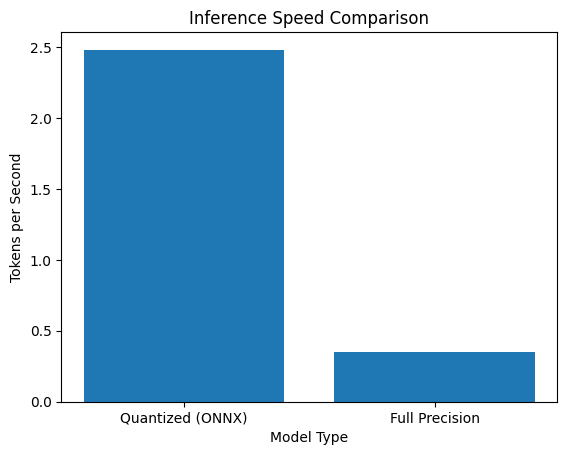

In [2]:

# -----------------------------
# RUN BOTH
# -----------------------------
onnx_speed = run_onnx()
fp_speed = run_full_precision()


# -----------------------------
# PLOT COMPARISON
# -----------------------------
models = ["Quantized (ONNX)", "Full Precision"]
speeds = [onnx_speed, fp_speed]

plt.figure()
plt.bar(models, speeds)
plt.xlabel("Model Type")
plt.ylabel("Tokens per Second")
plt.title("Inference Speed Comparison")
plt.show()

In [4]:
import psutil
import os
process = psutil.Process(os.getpid())
def get_memory():
    return process.memory_info().rss / (1024 ** 2)  

In [6]:
print("\n--- FULL PRECISION ---")
mem_before = get_memory()

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float32,
    device_map="cpu"
)
model.eval()

mem_after_load = get_memory()



fp_model_mem = mem_after_load - mem_before


print(f"Model Load Memory: {fp_model_mem:.2f} MB")


--- FULL PRECISION ---


Loading weights: 100%|██████████| 291/291 [00:17<00:00, 16.61it/s]


Model Load Memory: 23591.37 MB


In [7]:
del model

In [8]:
print("\n--- QUANTIZED (ONNX) ---")
mem_before = get_memory()

session = ort.InferenceSession(ONNX_PATH)

mem_after_load = get_memory()



onnx_model_mem = mem_after_load - mem_before


print(f"Model Load Memory: {onnx_model_mem:.2f} MB")


--- QUANTIZED (ONNX) ---
Model Load Memory: 6338.67 MB


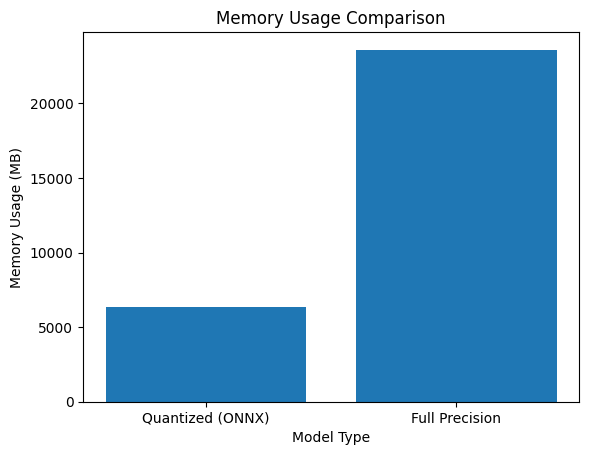

In [10]:
import matplotlib.pyplot as plt

models = ["Quantized (ONNX)", "Full Precision"]
memory = [onnx_model_mem, fp_model_mem]

plt.figure()
plt.bar(models, memory)
plt.xlabel("Model Type")
plt.ylabel("Memory Usage (MB)")
plt.title("Memory Usage Comparison")
plt.show()